**Task: Implement an advanced CNN with a spatial residual connection for the CIFAR-10 dataset.**

The CNN includes 3 convolutional layers on the main path:

Conv1: Input channels: 3; Output channels: 32; Kernel size: 3; Padding: 1; Stride: 1; ReLU activation

Pool1: MaxPool, Kernel size: (2,2); Padding: 0; Stride: 2

Conv2: Input channels: 32; Output channels: 64; Kernel size: 3; Padding: 1; Stride: 2; ReLU activation

Conv3: Input channels: 64; Output channels: 64; Kernel size: 3; Padding: 1; Stride: 2; ReLU activation

Skip_conv: A 1x1 Convolutional Layer. Input is the output of Pool1. Determine the required input channels, output channels, and stride so its output exactly matches the shape of Conv3.

The output of Skip_conv is added to the output of Conv3 before flattening.

The CNN has two fully connected layers. Flatten the added tensor. The width of the hidden layer (FC1) is 256, followed by ReLU activation and a Dropout layer (p=0.5). The final layer (FC2) outputs 10 classes.

Calculate the output dimensions for each layer, calculate the dimension after flattening, and implement the CNN. Tune hyperparameters to achieve >65% test accuracy.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

In [2]:
# Download the CIFAR10 dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [3]:
# Print the size of one sample
images, labels = next(iter(trainloader))
# Your reported result--------------------------------------------------
# Report the printed image size
print('Image size is '+str(images[0].shape))

Image size is torch.Size([3, 32, 32])


In [4]:
# -----------------------------
# Build the CNN
# -----------------------------

class CNN_residual(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_residual, self).__init__()

        # ---- Convolution layers ----
        # 32x32 -> 32x32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1)
        self.pool1 = nn.MaxPool2d(2,2)   # 32 -> 16

        # Your codes start here----------------------------------------------
        # Define Conv2 (16x16 -> 8x8)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)

        # Define Conv3 (8x8 -> 4x4)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=2)

        # ---- Spatial Skip connection (1x1 Convolution) ----
        # Input is from pool1 (16x16, 32 channels). Output must match conv3 (4x4, 64 channels).
        self.skip_conv = nn.Conv2d(32, 64, kernel_size=1, stride=4)

        # Calculate the correct flattened size for the main path
        FlattenSize = 64 * 4 * 4
        self.fc1 = nn.Linear(FlattenSize, 256)

        # Define a Dropout layer with p=0.5
        self.dropout = nn.Dropout(p=0.5)

        self.fc2 = nn.Linear(256, num_classes)
        # Your codes end here------------------------------------------------

    def forward(self, x):

        # ---- Conv Block 1 ----
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)                 # (N, 32, 16, 16)

        # Save for skip connection
        skip = x

        # Your codes start here----------------------------------------------
        # ---- Conv Block 2 & 3 ----
        # Apply Conv2 + ReLU 
        x = torch.relu(self.conv2(x))
        
        # Apply Conv3 + ReLU
        x = torch.relu(self.conv3(x))

        # Apply skip_conv to the saved 'skip' tensor
        skip = self.skip_conv(skip)

        # Add the spatial tensors BEFORE flattening!
        x = skip + x

        # ---- Main path flatten ----
        x = torch.flatten(x, 1)

        # ---- Dense layers with Dropout ----
        x = torch.relu(self.fc1(x))
        
        # Apply dropout here
        x = self.dropout(x)
        
        x = self.fc2(x)
        # Your codes end here------------------------------------------------

        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_residual().to(device)

In [14]:
# Define CrossEntropy Loss.
criterion = nn.CrossEntropyLoss()

# Your codes start here---------------------------------------
# Define Adam optimizer with your selected learning rate
LR = 0.001
optimizer = optim.Adam(model.parameters(), lr=LR)

# Choose your number of epochs
Epoch = 7
# Your codes end here-----------------------------------------

train_losses = []
test_accs = []

for epoch in range(Epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

    epoch_test_acc = 100. * test_correct / test_total
    test_accs.append(epoch_test_acc)

    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Train Acc: {100.*correct/total:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

Epoch 1 | Loss: 0.9113 | Train Acc: 67.28% | Test Acc: 64.63%
Epoch 2 | Loss: 0.8882 | Train Acc: 68.21% | Test Acc: 64.77%
Epoch 3 | Loss: 0.8680 | Train Acc: 68.75% | Test Acc: 65.01%
Epoch 4 | Loss: 0.8433 | Train Acc: 69.42% | Test Acc: 65.12%
Epoch 5 | Loss: 0.8225 | Train Acc: 70.26% | Test Acc: 65.58%
Epoch 6 | Loss: 0.8025 | Train Acc: 70.57% | Test Acc: 65.41%
Epoch 7 | Loss: 0.7853 | Train Acc: 71.27% | Test Acc: 65.49%


In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, targets in testloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

# Your reported result--------------------------------------------------
# Report the printed test accuracy
print(f"Test Accuracy: {100.*correct/total:.2f}%")

Test Accuracy: 65.49%


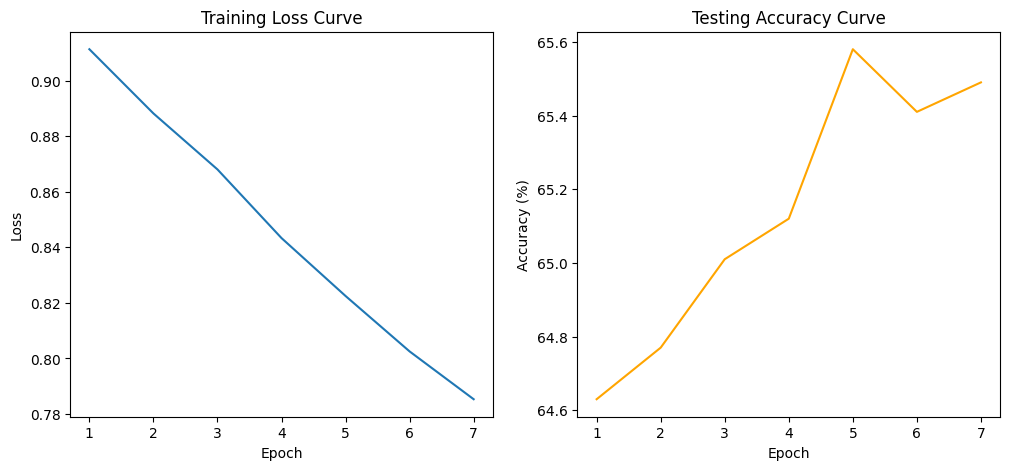

In [16]:
# -----------------------------
# Plot loss and accuracy curves
# -----------------------------
epochs_range = range(1, Epoch + 1)

plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

# Plot 2: Testing Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, test_accs, label='Test Accuracy', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Testing Accuracy Curve")

plt.show()

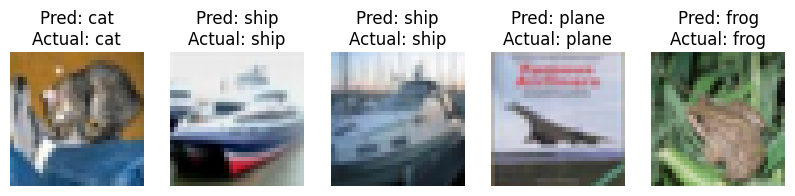

In [17]:
model.eval()
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    img = img / 2 + 0.5
    plt.imshow(img)
    plt.title(f"Pred: {classes[predicted[i]]}\nActual: {classes[labels[i]]}")
    plt.axis('off')
plt.show()